# Iris Dataset Explorer
### Task 1 — Exploring and Visualizing a Simple Dataset

This notebook walks through loading, summarizing, and visualizing the classic **Iris dataset**.
It covers descriptive statistics, scatter plots, histograms, box plots, violin plots, correlation heatmap, and ANOVA testing.

## Install Libraries

Before running anything, we make sure all required libraries are installed.
This cell uses `!pip install` which runs a terminal command directly from the notebook.
Run this cell **only once** — after that you can skip it.

**Key Points:**
- `pandas` → for data tables and summaries
- `numpy` → for math and array operations
- `matplotlib` → base plotting library
- `seaborn` → beautiful statistical charts
- `scipy` → for statistical tests like ANOVA
- `scikit-learn` → provides the built-in Iris dataset

## Import Libraries

Here we import all the libraries we need throughout the notebook.
We also apply a global theme using `seaborn` and set the plot resolution with `rcParams`.
All charts in this notebook will inherit this clean dark-grid style.

**Key Points:**
- `sns.set_theme()` → applies a consistent visual style to all plots
- `plt.rcParams["figure.dpi"]` → sets image sharpness (120 is good for notebooks)
- These imports are used in every single cell below

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
 
# Make plots look clean
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## Load the Iris Dataset

We load the Iris dataset directly from `sklearn` — no CSV file needed.
It is then converted into a `pandas` DataFrame so we can work with it easily.
A `species` column is added with readable names like `setosa`, `versicolor`, `virginica`.

**Key Points:**
- `load_iris()` → returns a dictionary-like object with data + labels
- `pd.DataFrame()` → converts raw numpy array into a table with column names
- `pd.Categorical.from_codes()` → maps 0/1/2 numbers to actual species names
- `df.head()` → shows the first 5 rows of the dataset

In [47]:
from sklearn.datasets import load_iris
 
iris_raw = load_iris()
df = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
df["species"] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)
 
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (150, 5)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Basic Dataset Info

This cell gives us a quick overview of the dataset structure.
We check column data types, null values, and how many samples belong to each species.
The dataset is perfectly balanced — 50 samples per species.

**Key Points:**
- `df.info()` → shows columns, data types, and non-null counts
- `df["species"].value_counts()` → counts how many rows per class
- Balanced classes mean no species is over/under-represented

In [48]:
print("Dataset Info:")
print("-" * 40)
df.info()
 
print("\nClass Distribution:")
print(df["species"].value_counts())

Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.0 KB

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Descriptive Statistics (Overall)

This cell computes summary statistics for all 4 numeric features across the whole dataset.
`describe()` is one of the most useful pandas functions — it gives a full statistical snapshot in one line.
These numbers help us understand the range, average, and spread of each feature.

**Key Points:**
- Shows `count`, `mean`, `std`, `min`, `25%`, `50%`, `75%`, `max`
- Petal features have larger variance than sepal features
- `.round(2)` keeps the output clean and readable

In [49]:
print("Overall Statistics:")
df.describe().round(2)

Overall Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## Statistics Per Species

Here we group the data by species and compute the mean of each feature.
This reveals how different the three species really are from each other numerically.
Virginica consistently has the largest petal dimensions, while Setosa has the smallest.

**Key Points:**
- `groupby("species").mean()` → splits data by class and averages each column
- Setosa has very small petals compared to the other two species
- This already hints that petal features will separate classes better than sepal features

In [50]:
print("Mean values per species:\n")
df.groupby("species").mean().round(2)

Mean values per species:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


## Scatter Plot (Petal Length vs Petal Width)

This scatter plot shows each flower as a point colored by species.
Petal dimensions are the most discriminating features — you can see clear separation between all three species.
Setosa forms a tight cluster far from the other two species.

**Key Points:**
- `groupby()` + loop → plots each species in its own color
- `alpha=0.8` → slight transparency so overlapping points are visible
- Setosa (teal) is completely separated; Versicolor and Virginica overlap slightly

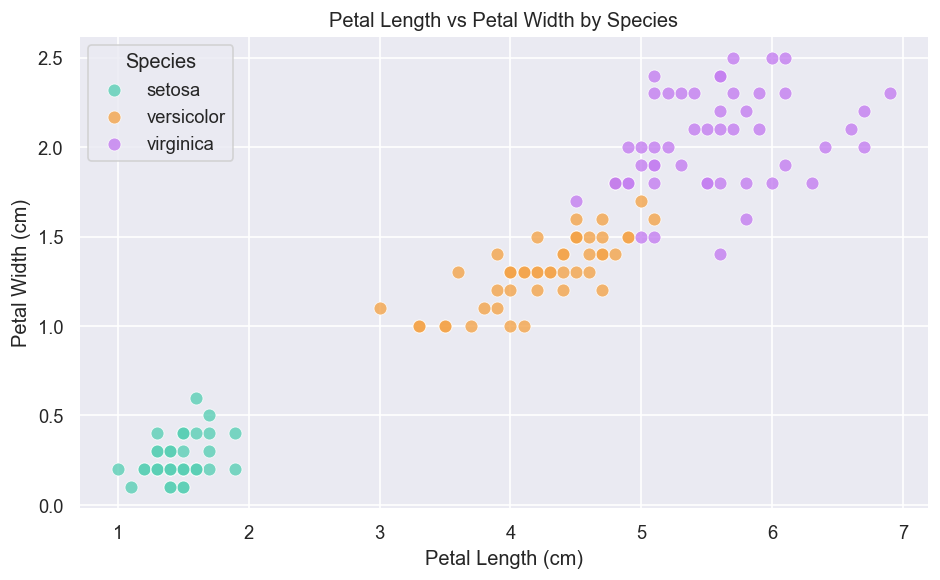

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
 
colors = {"setosa": "#5bcfb5", "versicolor": "#f4a44a", "virginica": "#c47ef0"}
 
for species, group in df.groupby("species"):
    ax.scatter(
        group["petal length (cm)"],
        group["petal width (cm)"],
        label=species,
        color=colors[species],
        alpha=0.8,
        edgecolors="white",
        linewidths=0.5,
        s=60
    )
 
ax.set_xlabel("Petal Length (cm)")
ax.set_ylabel("Petal Width (cm)")
ax.set_title("Petal Length vs Petal Width by Species")
ax.legend(title="Species")
plt.tight_layout()
plt.show()

## Scatter Plot (Sepal Length vs Sepal Width)

Same scatter plot but now using sepal measurements instead of petal.
Sepal features show much more overlap between species, especially Versicolor and Virginica.
This confirms that sepal dimensions alone are not enough to separate the classes cleanly.

**Key Points:**
- Sepal features have more overlap between species than petal features
- Setosa still separates well even with sepal measurements
- Comparing both scatter plots shows why petal features are better for classification

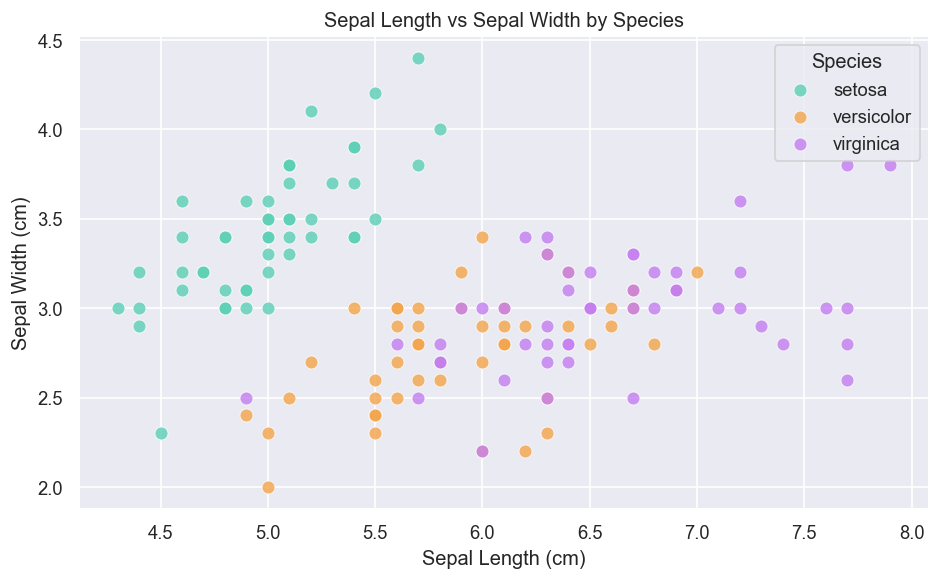

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))
 
for species, group in df.groupby("species"):
    ax.scatter(
        group["sepal length (cm)"],
        group["sepal width (cm)"],
        label=species,
        color=colors[species],
        alpha=0.8,
        edgecolors="white",
        linewidths=0.5,
        s=60
    )
 
ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Sepal Width (cm)")
ax.set_title("Sepal Length vs Sepal Width by Species")
ax.legend(title="Species")
plt.tight_layout()
plt.show()


## Pair Plot (All Feature Combinations)

A pair plot automatically creates scatter plots for every possible pair of features in one grid.
The diagonal shows a KDE (smooth distribution curve) for each feature per species.
This is the fastest way to visually explore all relationships in the dataset at once.

**Key Points:**
- `diag_kind="kde"` → diagonal shows smooth density curves instead of bars
- 4 features = 6 unique scatter plot combinations shown together
- Immediately reveals which feature pairs provide the best class separation

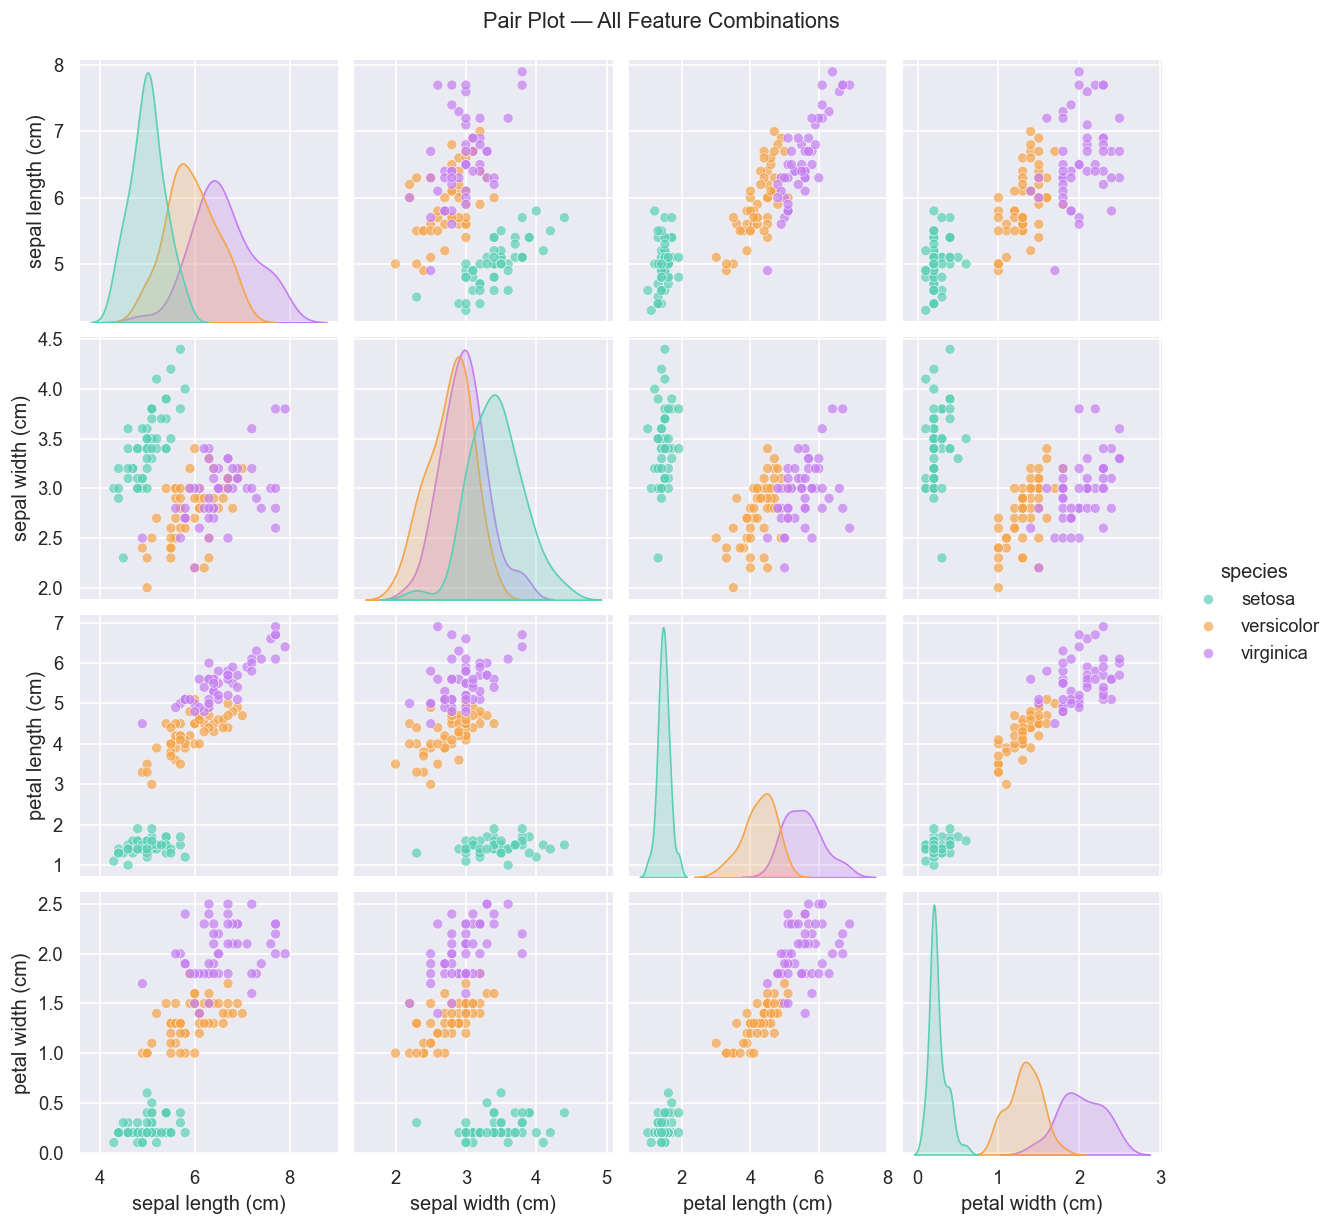

In [53]:
pair_colors = {"setosa": "#5bcfb5", "versicolor": "#f4a44a", "virginica": "#c47ef0"}
 
g = sns.pairplot(
    df,
    hue="species",
    palette=pair_colors,
    diag_kind="kde",       # diagonal: smooth distribution curve
    plot_kws={"alpha": 0.7, "edgecolor": "white", "linewidth": 0.4},
    height=2.5
)
g.fig.suptitle("Pair Plot — All Feature Combinations", y=1.02, fontsize=13)
plt.show()

## Histograms (Feature Distributions)

Histograms show how the values of each feature are distributed across the dataset.
By overlapping all three species on the same histogram, we can see which species differ most per feature.
Petal features show near-zero overlap between Setosa and the others — a strong visual signal.

**Key Points:**
- `bins=15` → divides the value range into 15 equal buckets
- `alpha=0.6` → makes bars semi-transparent so overlapping bars are visible
- 2×2 grid of subplots = one histogram per feature

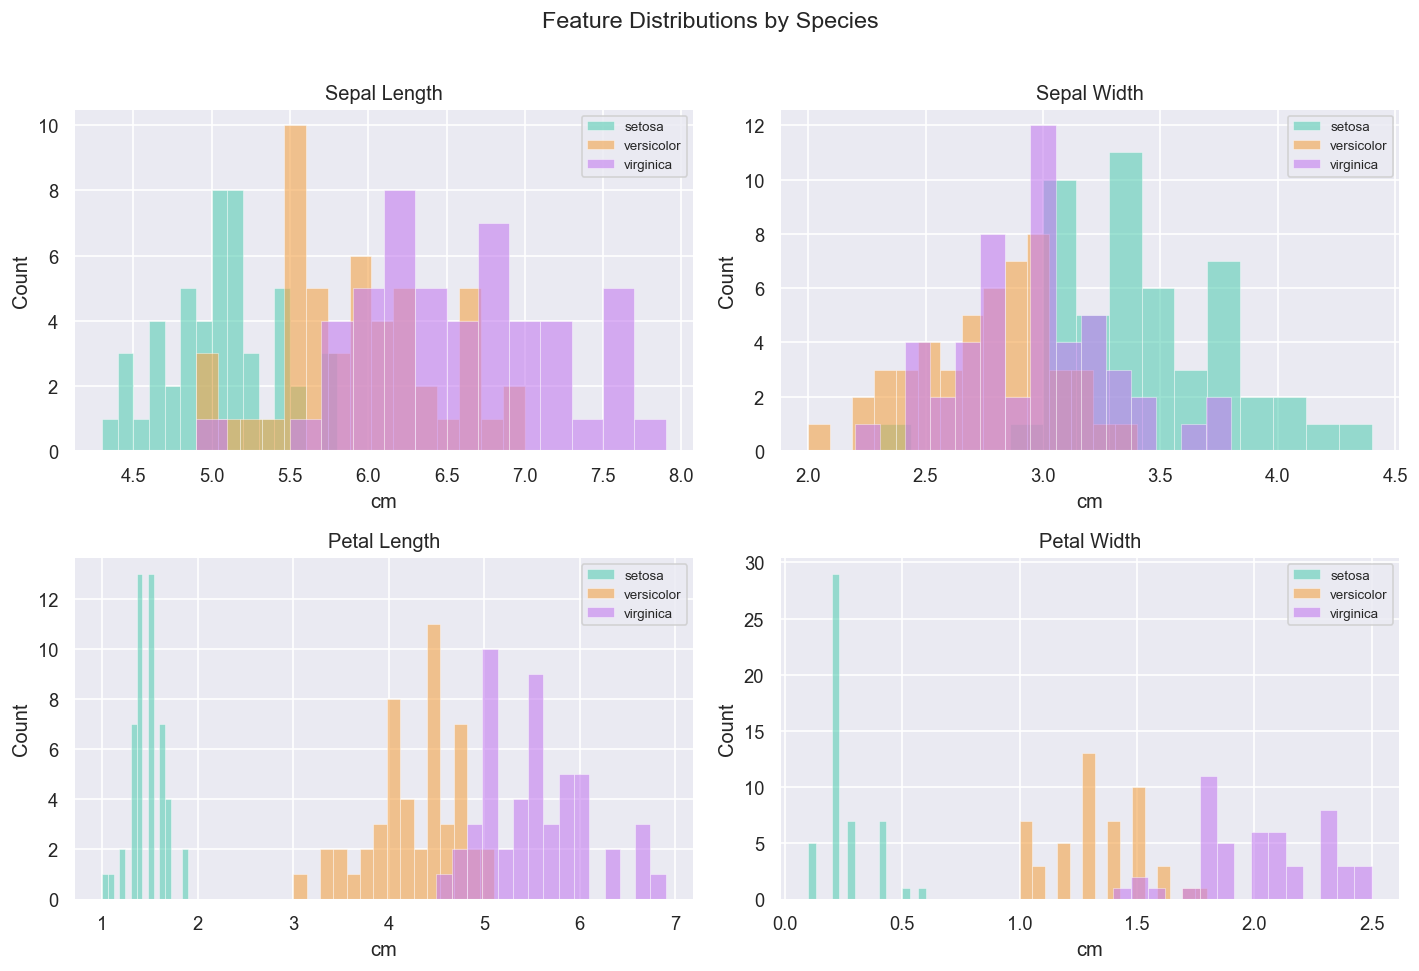

In [54]:
features = [col for col in df.columns if col != "species"]
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
 
for i, feature in enumerate(features):
    for species, group in df.groupby("species"):
        axes[i].hist(
            group[feature],
            bins=15,
            alpha=0.6,
            label=species,
            color=colors[species],
            edgecolor="white",
            linewidth=0.4
        )
    axes[i].set_title(feature.replace(" (cm)", "").title())
    axes[i].set_xlabel("cm")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)
 
fig.suptitle("Feature Distributions by Species", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Correlation Heatmap

A correlation heatmap shows how strongly each pair of features is related to each other.
Values close to `+1` mean strong positive correlation, `-1` means strong negative, `0` means no relation.
Petal Length and Petal Width have the highest correlation (~0.96) — they grow together.

**Key Points:**
- `df.corr()` → computes Pearson correlation coefficient for every pair of columns
- `annot=True` → prints the correlation number inside each cell
- Diagonal is always `1.0` because every feature is perfectly correlated with itself

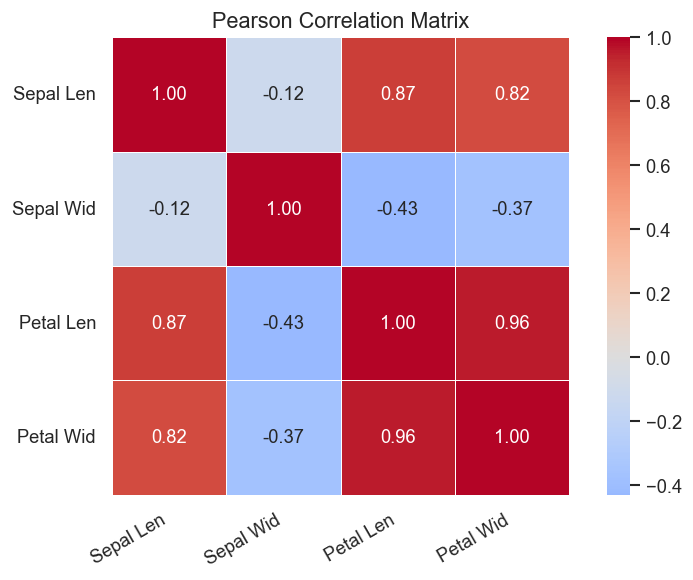


Correlation Table:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
sepal length (cm)               1.00             -0.12               0.87              0.82
sepal width (cm)               -0.12              1.00              -0.43             -0.37
petal length (cm)               0.87             -0.43               1.00              0.96
petal width (cm)                0.82             -0.37               0.96              1.00


In [58]:
corr = df[features].corr().round(2)
 
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    annot_kws={"size": 11}
)
ax.set_title("Pearson Correlation Matrix", fontsize=13)
# Shorten labels
short = ["Sepal Len", "Sepal Wid", "Petal Len", "Petal Wid"]
ax.set_xticklabels(short, rotation=30, ha="right")
ax.set_yticklabels(short, rotation=0)
plt.tight_layout()
plt.show()
 
print("\nCorrelation Table:")
print(corr.to_string())

## Bar Chart (Species Mean Comparison)

This grouped bar chart compares the average value of each feature across all three species side by side.
It is a clean way to see how each species differs numerically without looking at individual data points.
You can clearly see Virginica dominates in petal measurements while Setosa is the smallest.

**Key Points:**
- `groupby().mean().T.plot(kind="bar")` → transposes so features are on the X-axis
- `width=0.7` → controls how wide each group of bars is
- Good for quick side-by-side comparison of all species

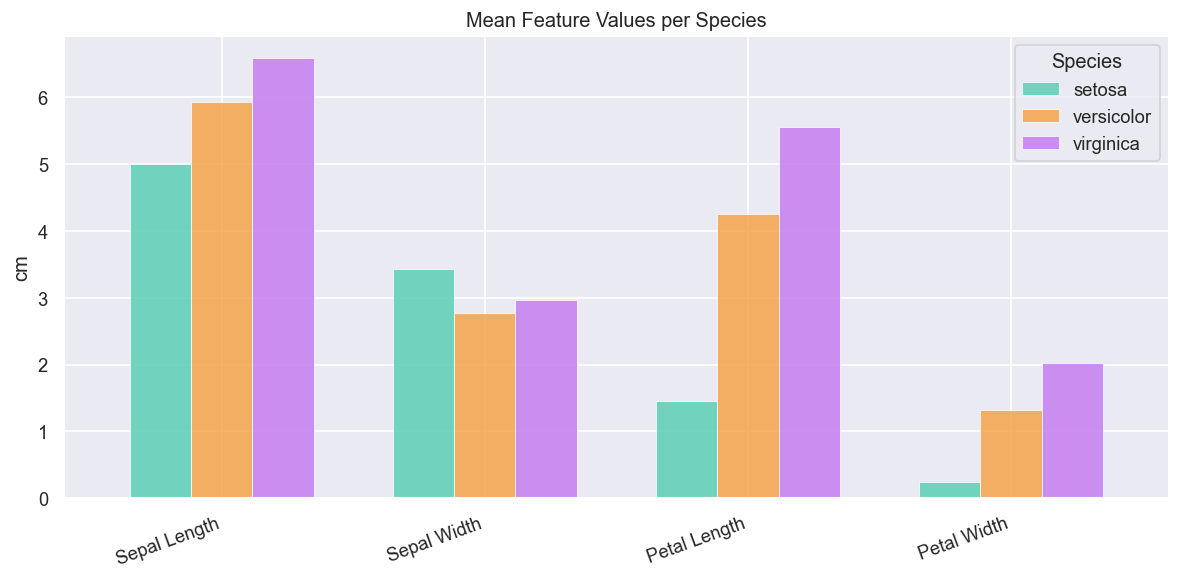

In [59]:
means = df.groupby("species")[features].mean()
 
means.T.plot(
    kind="bar",
    figsize=(10, 5),
    color=[colors["setosa"], colors["versicolor"], colors["virginica"]],
    edgecolor="white",
    linewidth=0.5,
    width=0.7,
    alpha=0.85
)
 
plt.title("Mean Feature Values per Species")
plt.ylabel("cm")
plt.xlabel("")
plt.xticks(
    ticks=range(4),
    labels=["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"],
    rotation=20,
    ha="right"
)
plt.legend(title="Species")
plt.tight_layout()
plt.show()
 

## ANOVA Test + Key Insights
ANOVA (Analysis of Variance) is a statistical test that checks if the means of a feature are significantly different across species.
A very small `p-value` (less than 0.05) means the difference between species is real — not by chance.
All 4 features pass this test, confirming that every feature is statistically meaningful for separating species.

**Key Points:**
- `stats.f_oneway()` → takes 3 groups and returns F-statistic and p-value
- `p < 0.05` → statistically significant difference between species
- High F-statistic for petal features confirms they are the most discriminating features

In [60]:
print("=" * 50)
print("KEY INSIGHTS FROM IRIS DATASET")
print("=" * 50)
 
for feature in features:
    f_stat, p_val = stats.f_oneway(
        df[df["species"] == "setosa"][feature],
        df[df["species"] == "versicolor"][feature],
        df[df["species"] == "virginica"][feature]
    )
    sig = "✓ Significant" if p_val < 0.05 else "✗ Not significant"
    print(f"\n{feature}")
    print(f"  F-statistic : {f_stat:.2f}")
    print(f"  p-value     : {p_val:.2e}  →  {sig}")
 
print("\n" + "=" * 50)
print("Strong positive correlation:")
print(f"  Petal Length vs Petal Width : {corr.loc['petal length (cm)','petal width (cm)']:.2f}")
print(f"  Sepal Length vs Petal Length: {corr.loc['sepal length (cm)','petal length (cm)']:.2f}")
print(f"  Sepal Length vs Petal Width : {corr.loc['sepal length (cm)','petal width (cm)']:.2f}")
 

KEY INSIGHTS FROM IRIS DATASET

sepal length (cm)
  F-statistic : 119.26
  p-value     : 1.67e-31  →  ✓ Significant

sepal width (cm)
  F-statistic : 49.16
  p-value     : 4.49e-17  →  ✓ Significant

petal length (cm)
  F-statistic : 1180.16
  p-value     : 2.86e-91  →  ✓ Significant

petal width (cm)
  F-statistic : 960.01
  p-value     : 4.17e-85  →  ✓ Significant

Strong positive correlation:
  Petal Length vs Petal Width : 0.96
  Sepal Length vs Petal Length: 0.87
  Sepal Length vs Petal Width : 0.82
